<a href="https://colab.research.google.com/github/mfauzanadhimh/Image_Enchancement_FIltering/blob/main/PCD_Assigment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.color import rgb2gray
from google.colab import drive
drive.mount('/content/drive')

img_noise = cv2.imread('/content/drive/My Drive/pcd/filtering/img_noise.jpg')
img_blur = cv2.imread('/content/drive/My Drive/pcd/filtering/img_blur.jpg')
img_dark = cv2.imread('/content/drive/My Drive/pcd/filtering/img_dark.png')
img_bright = cv2.imread('/content/drive/My Drive/pcd/filtering/img_bright.JPG')
img_low_contrast = cv2.imread('/content/drive/My Drive/pcd/filtering/images_low_contrast.jpg')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#Median Filter

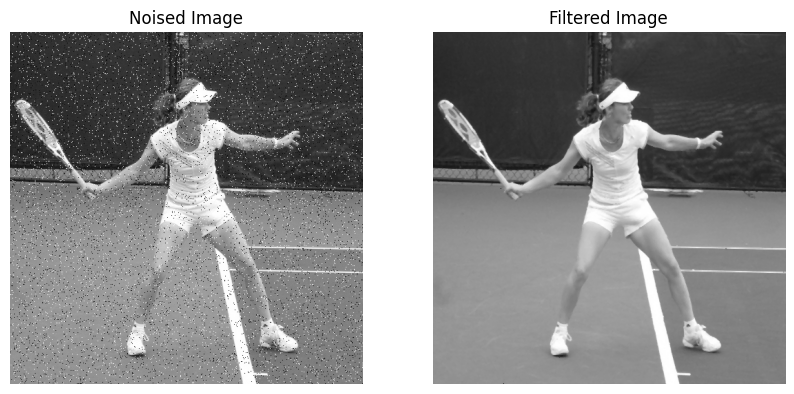

In [9]:
img = img_noise.copy()

def median_filter(img, kernel):
  H, W, C = img.shape
  pad = kernel // 2

  padded = np.pad(img,  ((pad, pad), (pad, pad), (0, 0)), mode ='edge')
  output = np.zeros_like(img)

  for i in range(H):
    for j in range(W):
      window = padded[i:i+kernel, j:j + kernel]

      for c in range(C):
        output[i,j,c] = np.median(window[:,:,c])

  return output.astype(np.uint8)

result_median = median_filter(img, 3)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Noised Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(result_median)
plt.title("Filtered Image")
plt.axis("off")

plt.show()

#Image Sharpening

Max perubahan piksel: 238
Rata-rata perubahan: 29.442701445685493


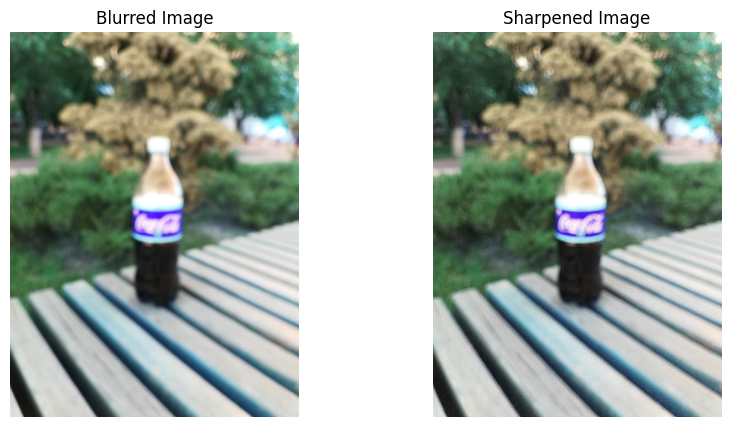

#Histogram Equalization

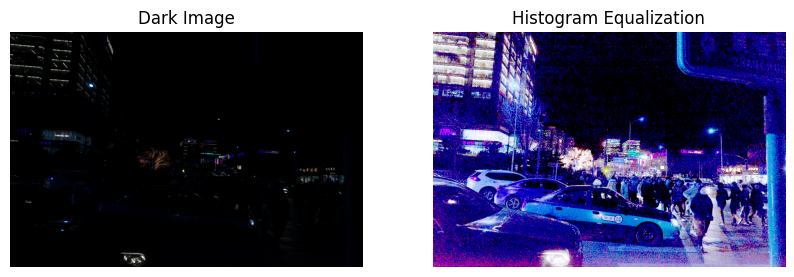

In [12]:
img = img_dark

def histogram_equalization(img):
    H, W, C = img.shape

    output = np.zeros_like(img)

    for c in range(C):

        histogram = np.zeros(256)

        for i in range(H):
            for j in range(W):
                pixel = img[i, j, c]
                histogram[pixel] += 1

        cdf = np.cumsum(histogram)
        cdf_min = cdf[cdf > 0][0]

        mapping = (
            (cdf - cdf_min)
            / ((H * W) - cdf_min)
            * 255
        )

        mapping = np.clip(mapping, 0, 255).astype(np.uint8)

        for i in range(H):
            for j in range(W):
                old_pixel = img[i, j, c]
                output[i, j, c] = mapping[old_pixel]

    return output


result_histogram = histogram_equalization(img)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Dark Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(result_histogram)
plt.title("Histogram Equalization")
plt.axis("off")

plt.show()

#Gamma Correction

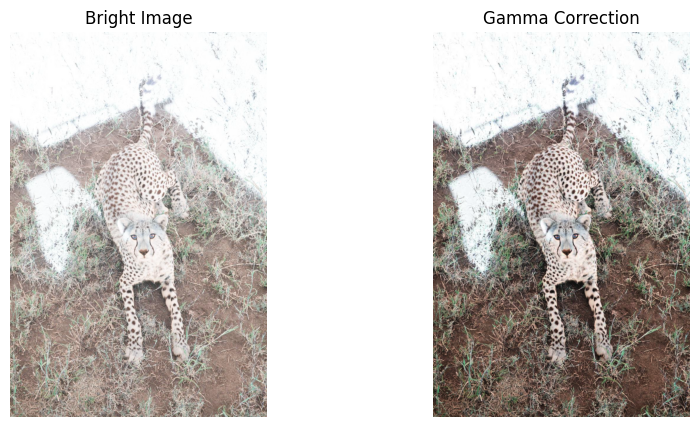

In [13]:
img = img_bright.copy()

def gamma_correction(img, gamma):
    H, W, C = img.shape

    output = np.zeros_like(img)

    for i in range(H):
        for j in range(W):
            for c in range(C):

                pixel = img[i, j, c] / 255.0

                corrected = pixel ** gamma
                output[i, j, c] = corrected * 255

    return output.astype(np.uint8)


result_gamma = gamma_correction(img, 2.0)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Bright Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(result_gamma)
plt.title("Gamma Correction")
plt.axis("off")

plt.show()

#Contrast Stretching


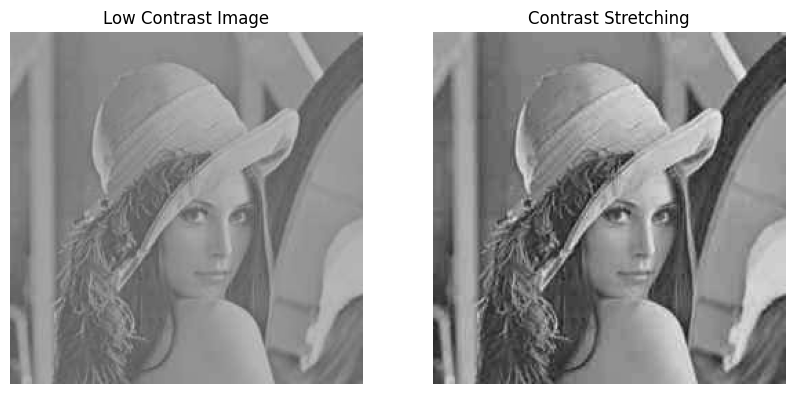

In [14]:
import numpy as np
import matplotlib.pyplot as plt

img = img_low_contrast.copy()

def contrast_stretching(img):
    H, W, C = img.shape

    output = np.zeros_like(img)

    for c in range(C):

        min_pixel = np.min(img[:, :, c])
        max_pixel = np.max(img[:, :, c])

        for i in range(H):
            for j in range(W):

                pixel = img[i, j, c]

                stretched = (
                    (pixel - min_pixel)
                    / (max_pixel - min_pixel)
                    * 255
                )

                output[i, j, c] = stretched

    return output.astype(np.uint8)


result_contrast= contrast_stretching(img)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Low Contrast Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(result_contrast)
plt.title("Contrast Stretching")
plt.axis("off")

plt.show()

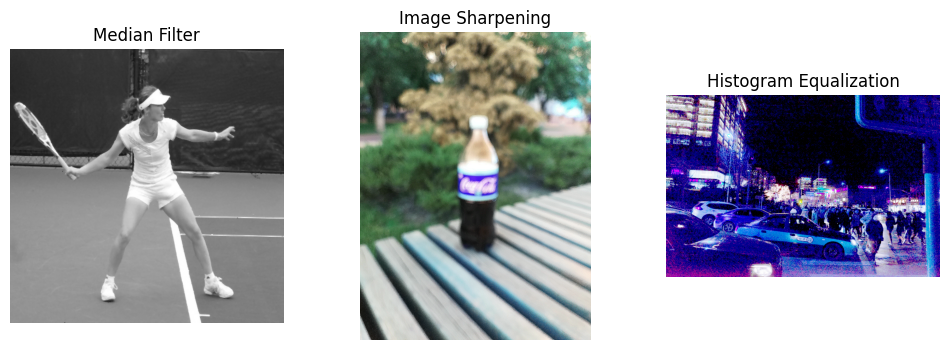

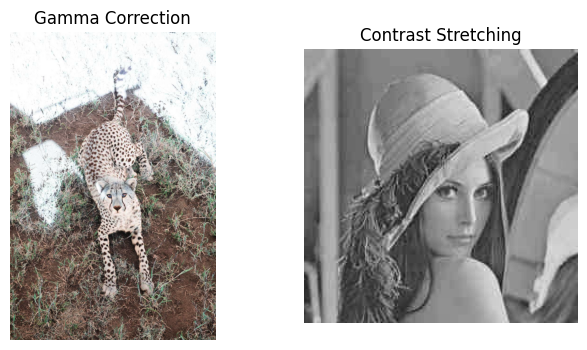

In [16]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(result_median)
plt.axis("off")
plt.title("Median Filter")

plt.subplot(1, 3, 2)
plt.imshow(result_sharpening)
plt.axis("off")
plt.title("Image Sharpening")

plt.subplot(1, 3, 3)
plt.imshow(result_histogram)
plt.axis("off")
plt.title("Histogram Equalization")


plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(result_gamma)
plt.axis("off")
plt.title("Gamma Correction")

plt.subplot(1, 3, 2)
plt.imshow(result_contrast)
plt.axis("off")
plt.title("Contrast Stretching")

plt.show()